# **From Recurrent Neural Network to Large Language Models: Practical Sentiment Analysis on Movie Reviews**

This lab session explores how the same NLP task sentiment analysis can be tackled using different approaches from classical neural networks to modern language models.

- **TL;DR:** Understanding and Implementing a Vanilla Recurrent Neural Network from Scratch
- **Objective:** Explore the fundamentals of **Recurrent Neural Networks (RNNs)** and their role in **generative tasks** by building one from scratch using NumPy with a focus on sentiment analysis.

In this session, you will bridge the gap between classical neural networks and modern language models by applying both a **Vanilla Recurrent Neural Network (RNN)** (built from scratch) and a **pre-trained language model** to perform **sentiment analysis** on movie reviews.

Through hands-on coding, you will first understand how an RNN processes text sequentially, maintaining context across time steps. Next you will then deploy a **small LM** (e.g., `Qwen/Qwen2-0.5B`, `DistilBERT`) to predict movie sentiments comparing its performance, efficiency and interpretability to the custom-built RNN.

This exercise emphasizes the evolution from fundamental sequence models to modern transformer-based architectures showing how small LLMs can bring powerful NLP capabilities into classroom-scale experiments.


### Learning Goals

* Understand how RNNs and LLMs **handle sequential data differently**.
* Implement a **Vanilla RNN** from scratch using NumPy.
* Apply the RNN to a **toy sentiment dataset** to see how it generates predictions for sequential inputs.
* Observe the **flow of information across time steps** and the challenges of handling real-world text, like unseen words.
* Apply a **small pre-trained language model** for real-world sentiment prediction.
* Compare model performance, inference time and computational efficiency.
* Discuss trade-offs between **building from scratch** and **using pre-trained models**.

### What is sentiment analysis?
Sentiment analysis is the process of analyzing digital text to determine whether the emotional tone of the message is positive, negative or neutral. Today, companies have large volumes of textual data at their disposal, such as emails, transcripts of customer support conversations, social media comments and reviews. Sentiment analysis tools can analyze this text to automatically determine the author's attitude toward a topic. Companies use the insights gained from sentiment analysis to improve customer service and strengthen their brand reputation.

### Why is sentiment analysis important?
Sentiment analysis helps companies improve their products and services. Below are [some of the benefits of sentiment analysis](https://aws.amazon.com/what-is/sentiment-analysis/?nc1=h_ls):
- **Provide objective insights:** Companies can avoid the personal biases associated with human evaluators by using artificial intelligence (AI)-based sentiment analysis tools. This allows them to obtain consistent and objective results when analyzing customer opinions.
- **Build better products and services:** A sentiment analysis system helps companies improve their products and services based on genuine and specific customer feedback.
- **Real-time results:** Businesses must be quick to respond to potential crises or market trends in today's fast-changing landscape. Companies rely on sentiment analysis software to learn what customers feel about the company's brand, products and services in real time and take immediate actions based on their findings.

### **Practical Session (TD) Overview**

This TD is divided into 4 parts:

## **Part I: Sentiment Analysis with RNN**

We will implement a **Vanilla Recurrent Neural Network (RNN)** from scratch using NumPy to classify movie reviews as positive or negative. RNNs are designed for **sequential data**, like text, time series or speech.

* Implement a sentiment analysis system using a **Vanilla RNN**.
* Convert text to numerical vectors with one-hot encoding.
* Enhance the RNN with an **out-of-vocabulary token**.
* Build a simple **Streamlit interface** for your system.

By themselves RNNs are not inherently generative or discriminative they are just a neural network architecture:
* **Generative use:** Predict the next token in a sequence (e.g., language generation or music generation).
* **Discriminative use:** Classify sequences (e.g., sentiment analysis). In Part I, we use the RNN as a **discriminative model**.

## **Part II: Sentiment Analysis with a Small Language Model (SLM)**

We will use a language model instead of an RNN. Until 2017, RNNs were state-of-the-art for many NLP tasks, but the introduction of the [Transformer](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf) architecture changed that. In this part, we will download a small language model (since large language models require resources we don't have) and learn how to generate text with it. Unlike the one-hot encoding used with RNNs, we will use a pretrained tokenizer. The model doesn’t take raw text but token IDs as input. We will also learn how to decode the generated output back into natural text. After understanding text generation with a small language model, we will use this model without further training to perform sentiment classification. Unlike the RNN, we don't train the model on the dataset instead we rely on **few-shot prompting** to perform sentiment classification. This highlights the advantages of **transfer learning**: LLMs can generalize tasks and reduce development effort even if they require more computational resources.

## **Part III: Sentiment Analysis with Tensorflow**
In this part, we will build a neural network from scratch using TensorFlow Keras to classify [IMDB movie](https://www.imdb.com/) reviews as `"positive"` or `"negative"`. This pipeline mirrors how ML models are deployed in industry. We will implment form scratch a Keras model that will uses:

* **Embedding layer** to represent words as dense vectors
* **Dropout layers** to prevent overfitting
* **GlobalAveragePooling1D** to summarize sequences
* **Dense layer with sigmoid activation** for binary classification

Together, these 3 parts show a progression from **manual model building** (RNN), to **pre-trained small models** (SLM) to **production-ready deep learning pipelines** (Keras/TensorFlow).


##### Key Takeaways

* RNNs and LLMs both handle sequential data but in fundamentally different ways.
* RNNs require training from scratch but give insight into sequence processing.
* Language models (SLM, LM or LLMs) allow task generalization with minimal training.
* TensorFlow Keras demonstrates industrial deployment and modern ML pipelines.

This lab will demonstrates that the **same task can be approached in multiple ways**, emphasizing the trade-offs between **manual implementation, model reuse and computational efficiency**.


## **Part IV: Extend the Model – Deliverable**
For this final part, you will individually submit a notebook demonstrating how you can extend the models from previous parts:

* **Parts I & II:** Modify the RNN and the small language model to include a third sentiment class: **neutral**, in addition to positive and negative.
* **Part III:** Adapt the TensorFlow Keras model, originally trained as a binary classifier on the IMDB dataset, to handle **multi-class classification**. Specifically, you will train the model to predict the tag of a programming question from the Stack Overflow dataset.


### **Important Note for Students**
This lab session spans **3 hours over two sessions**. The goal is to show that the **same task—sentiment or text classification—can be approached in multiple ways**, ranging from building models from scratch to leveraging pre-trained architectures.

This TD is **self-contained**: all answers and explanations are integrated within the notebook.
We have **intentionally included some errors**, such as:

```
ValueError: shapes (1,19) and (18,64) not aligned
```

This is designed to encourage you to **learn through trial and error**. After each code block in the notebook, you will find explanations and interpretations to guide your understanding.

---

# Part I: Sentiment Analysis With Recurrent Neural Networks

## 1️ Concept: Rolled vs. Unrolled RNN

[Recurrent Neural Networks (RNNs)](https://arxiv.org/pdf/1912.05911) are a special kind of neural network designed to handle *sequences* of data such as sentences, audio or time series. For many years, RNNs were the state-of-the-art model for Natural Langauge Processing tasks before the rise of Transformers thanks to their ability to retain context across time steps. They played a crucial role in paving the way for today’s generative AI performance by introducing the idea of maintaining context across time steps.

This mechanism of maintaining and propagating information laid the foundation for today’s generative AI models. Modern architectures, like Transformers, build on these ideas using attention mechanisms instead of recurrence to achieve much higher performance in text generation, translation, summarization, etc.

RNNs can be visualized in two ways:

- **Rolled RNN:** A compact representation of the network showing recursion (the hidden layer loops back to itself).
- **Unrolled RNN:** The same network expanded through time steps to visualize how information passes forward.

Below is an illustration of this concept:
<p align="center">
<img src="https://i.sstatic.net/BSzow.png" width="400" >
</p>


> **Question:** Why is the unrolled version useful when training RNNs?  
> **Hint:** It allows us to see how gradients flow through time this is the basis for *Backpropagation Through Time (BPTT)*.


**Answer:** The unrolled version of an RNN is useful because it shows how information and gradients flow through each time step, which is essential for Backpropagation Through Time (BPTT) to correctly update the network's weights across the sequence.


## 2️ Imports and Dataset

Let's start by importing dependencies and preparing a small text-based dataset for binary sentiment classification (positive or negative).


In [1]:
#Step 1: Import necessary libraries
from tqdm import tqdm  #tqdm is used to show progress bars during loops (useful for long computations).
import numpy as np

### Step 2: Create a toy dataset
We create a small toy dataset for sentiment classification. Each sentence has a label to indicate whether it is positive (1) or negative (0).

- train_X contains training sentences.
- train_y contains corresponding labels (1 = positive, 0 = negative sentiment).
- test_X and test_y are for evaluating the model after training.

In [2]:
# Toy sentiment dataset
train_X = ['good', 'bad', 'happy', 'sad', 'not good', 'not bad', 'not happy', 'not sad', 'very good', 'very bad', 
           'very happy', 'very sad', 'i am happy', 'this is good', 'i am bad', 'this is bad', 'i am sad', 'this is sad', 
           'i am not happy', 'this is not good', 'i am not bad', 'this is not sad', 'i am very happy', 'this is very good', 
           'i am very bad', 'this is very sad', 'this is very happy', 'i am good not bad', 'this is good not bad', 
           'i am bad not good', 'i am good and happy', 'this is not good and not happy', 'i am not at all good', 
           'i am not at all bad', 'i am not at all happy', 'this is not at all sad', 'this is not at all happy', 
           'i am good right now', 'i am bad right now', 'this is bad right now', 'i am sad right now', 'i was good earlier', 
           'i was happy earlier', 'i was bad earlier', 'i was sad earlier', 'i am very bad right now', 'this is very good right now', 
           'this is very sad right now', 'this was bad earlier', 'this was very good earlier', 'this was very bad earlier', 
           'this was very happy earlier', 'this was very sad earlier', 'i was good and not bad earlier', 
           'i was not good and not happy earlier', 'i am not at all bad or sad right now', 'i am not at all good or happy right now', 
           'this was not happy and not good earlier']

train_y = [1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 
           1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 
           0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0]

test_X = ['this is happy', 'i am good', 'this is not happy', 'i am not good', 'this is not bad', 'i am not sad', 
          'i am very good', 'this is very bad', 'i am very sad', 'this is bad not good', 'this is good and happy', 
          'i am not good and not happy', 'i am not at all sad', 'this is not at all good', 'this is not at all bad', 
          'this is good right now', 'this is sad right now', 'this is very bad right now', 'this was good earlier', 
          'i was not happy and not good earlier']
test_y = [1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]

### Step 3 Build the vocabulary
This step creates a vocabulary of all words in the training data.

Example: If your sentences are ["good", "very good"], the vocabulary is {"good", "very"}.

- Split each sentence into words and collect all unique words.
- Count the total number of unique words.

In [3]:
# TODO: Vocabulary setup
vocab = set([word for text in train_X for word in text.split()])
vocab_size = len(vocab)
print(vocab_size)

18


### Step 4 Map words to indices

- Assign a unique index to each word in the vocabulary.
- This helps convert words into numbers, which a machine learning model can understand.

Example: {"good": 0, "bad": 1, "happy": 2, ...}

In [4]:
# TODO: word_to_index dictionary
word_to_index = {w:i for i, w in enumerate(vocab)}

Print the vocabulary dictionary to understand how words are indexed.


In [5]:
# TODO: Print the word_to_index mapping
print(word_to_index)

{'was': 0, 'this': 1, 'am': 2, 'is': 3, 'i': 4, 'happy': 5, 'bad': 6, 'right': 7, 'good': 8, 'all': 9, 'not': 10, 'now': 11, 'at': 12, 'very': 13, 'sad': 14, 'earlier': 15, 'and': 16, 'or': 17}


### Step 5 One-Hot Encoding

Before feeding text into the RNN, we must convert each word into a vector this is done using *one-hot encoding*.

#### **Why do we encode words?**

* Computers **cannot understand words** directly. They only understand numbers.
* **One-hot encoding** turns each word into a vector of 0s and 1s so the computer can work with it.
* Example:

  * Vocabulary = `["good", "bad", "happy"]`
  * `"happy"` → `[0, 0, 1]`
* Each word gets a unique “digital fingerprint” that the RNN can read.

**Simple analogy:**
Think of it like giving each word its own ID card. Without it the computer doesn't know which word is which.

This is also how advanced models like Transformers (ChatGPT) predict the next token. Words are first converted into numbers so the model can understand them. In our RNN example we use one-hot encoding while Transformers use embeddings, which capture meaning and context. But both also need weight initialization to start learning properly ensuring the model trains faster and more reliably.

In [6]:
def oneHotEncode(text):
    inputs = []
    for word in text.split():
        vector = np.zeros((1, vocab_size))
        vector[0][word_to_index[word]] = 1
        inputs.append(vector)
    return inputs

# Xavier Initialization
def initWeights(input_size, output_size):
    return np.random.uniform(-1, 1, (input_size, output_size)) * np.sqrt(6 / (input_size + output_size))

In [7]:
# TODO: Test encoding function
sample = "i am happy"
encoded = oneHotEncode(sample)
print(f"Encoded shapes: {[v.shape for v in encoded]}")

Encoded shapes: [(1, 18), (1, 18), (1, 18)]


### Step 6: Weight Initialization

##### **Why do we initialize weights?**

* Weights are numbers that **control how the neural network learns**.
* If we start with all zeros or numbers too big/small, the network **won’t learn properly**.
* **Xavier initialization** picks starting numbers carefully so learning is smooth and faster.

**Simple analogy:**
Think of it like planting seeds in a garden. If you plant them too deep or too shallow, the plants (the network) won't grow properly. Proper initialization gives them the right start.

* **Xavier initialization** ensures that the weights are not too small or too large, helping the neural network **train faster and avoid vanishing/exploding gradients**.

In [8]:
def initWeights(input_size, output_size):
    return np.random.uniform(-1, 1, (input_size, output_size)) * np.sqrt(6 / (input_size + output_size))

In [9]:
### **Testing One-Hot Encoding (optional)**
sample = "i am happy and"
encoded = oneHotEncode(sample)
print(f"Encoded shapes: {[v.shape for v in encoded]}")#each token in the sample will be a one hot enoceded vector of shape 1,18
print(f"Encoded: {encoded[0]}")

Encoded shapes: [(1, 18), (1, 18), (1, 18), (1, 18)]
Encoded: [[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## 3 Building the RNN Class

We will implement a simple RNN with 3 main parts:

1. **Forward propagation** processes inputs one step at a time.  
2. **Backward propagation**  updates weights through time (*BPTT*).  
3. **Train/Test methods** loops through data and evaluates accuracy.


### Step 7: Activation Functions

In [10]:
def tanh(x, derivative=False):
    if derivative:
        return 1 - (x ** 2)
    return np.tanh(x)

def softmax(x):
    exp = np.exp(x - np.max(x))
    return exp / np.sum(exp)

Instruction for students:
- tanh is used for hidden layer activation it squashes values between -1 and 1.
- softmax converts the final output into probabilities (values betwen 0 and 1) for each class (positive or negative sentiment).
- When training we sometimes need the derivative of tanh for backpropagation.

Explanation:
- tanh adds non-linearity so the network can learn complex patterns.
- softmax is commonly used for classification tasks.


## 4 Initialize the RNN Class

In [11]:
# Step 8 
class RNN:
    def __init__(self, input_size, hidden_size, output_size, num_epochs, learning_rate):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

        # Network
        self.w1 = initWeights(input_size, hidden_size)
        self.w2 = initWeights(hidden_size, hidden_size)
        self.w3 = initWeights(hidden_size, output_size)

        self.b2 = np.zeros((1, hidden_size))
        self.b3 = np.zeros((1, output_size))

    def forward(self, inputs):# Forward Propogation
        self.hidden_states = [np.zeros_like(self.b2)]
        for x in inputs:
            layer1 = np.dot(x, self.w1)
            layer2 = np.dot(self.hidden_states[-1], self.w2) + self.b2
            self.hidden_states.append(tanh(layer1 + layer2))
        return np.dot(self.hidden_states[-1], self.w3) + self.b3

    def backward(self, error, inputs):# Backward Propogation
        d_b3 = error
        d_w3 = np.dot(self.hidden_states[-1].T, error)

        d_b2 = np.zeros_like(self.b2)
        d_w2 = np.zeros_like(self.w2)
        d_w1 = np.zeros_like(self.w1)

        d_hidden = np.dot(error, self.w3.T)

        for t in reversed(range(len(inputs))):
            d_hidden *= tanh(self.hidden_states[t + 1], derivative=True)
            d_b2 += d_hidden
            d_w2 += np.dot(self.hidden_states[t].T, d_hidden)
            d_w1 += np.dot(inputs[t].T, d_hidden)
            d_hidden = np.dot(d_hidden, self.w2)

        for grad in (d_b3, d_w3, d_b2, d_w2, d_w1):
            np.clip(grad, -1, 1, out=grad)

        self.b3 += self.learning_rate * d_b3
        self.w3 += self.learning_rate * d_w3
        self.b2 += self.learning_rate * d_b2
        self.w2 += self.learning_rate * d_w2
        self.w1 += self.learning_rate * d_w1

    def train(self, X, y):
        for _ in tqdm(range(self.num_epochs)):
            for text, label in zip(X, y):
                inputs = oneHotEncode(text)
                pred = self.forward(inputs)
                error = -softmax(pred)
                error[0][label] += 1
                self.backward(error, inputs)

    def test(self, X, y):
        correct = 0
        for text, label in zip(X, y):
            inputs = oneHotEncode(text)
            pred = self.forward(inputs)
            prediction = np.argmax(pred)
            print(text, "=>", ["Negative", "Positive"][prediction])
            if prediction == label:
                correct += 1
        print(f"Accuracy: {round(100 * correct / len(X), 2)}%")


## 5️ Training the RNN
Initialize and train our RNN on the training data.


In [12]:
rnn = RNN(input_size=vocab_size, hidden_size=64, output_size=2, learning_rate=0.02, num_epochs=1000)
rnn.train(train_X, train_y)

100%|██████████| 1000/1000 [00:06<00:00, 165.41it/s]



## 6️ Testing the Model


In [13]:
rnn.test(test_X, test_y)

this is happy => Positive
i am good => Positive
this is not happy => Negative
i am not good => Negative
this is not bad => Positive
i am not sad => Positive
i am very good => Positive
this is very bad => Negative
i am very sad => Negative
this is bad not good => Negative
this is good and happy => Positive
i am not good and not happy => Negative
i am not at all sad => Positive
this is not at all good => Negative
this is not at all bad => Positive
this is good right now => Positive
this is sad right now => Negative
this is very bad right now => Negative
this was good earlier => Positive
i was not happy and not good earlier => Negative
Accuracy: 100.0%



## 7️ Try It Yourself

Predict sentiment for a custom sentence.


In [14]:
sentence = "a bloody bad movie"
encoded = oneHotEncode(sentence)
prediction = rnn.forward(encoded)
print(['Negative', 'Positive'][np.argmax(prediction)])

KeyError: 'a'

### What Caused the Error

Yes this error is a classic example of a **real-world issue in language modeling** often referred to in NLP as an **Out-of-Vocabulary (OOV)** problem.

Here is what is happening step-by-step:

* The vocabulary (`word_to_index`) was built **only from the training data** (`train_X`).
* The test sentence `"a bloody bad movie"` includes **words that never appeared during training** specifically `"a"`, `"bloody"` and `"movie"`.
* When the `oneHotEncode()` function tries to look up these unseen words it fails because they are not in the dictionary resulting in a `KeyError`.



#### In Practice

In larger NLP systems (and modern LLMs) unseen words are handled using **subword tokenization** (like Byte-Pair Encoding or WordPiece) which eliminates true OOV issues.
For small toy models like this one simply ignoring or mapping unknown tokens to `<UNK>` is a practical fix.


#### Option 1 a Quick Fix

To make the model more robust we have 2 options: we can modify the `oneHotEncode()` function to **ignore unknown words** or represent them with a special `<UNK>` (unknown) token.

In [ ]:
def oneHotEncode(text):
    inputs = []
    for word in text.split():
        if word not in word_to_index:
            # skip unknown words
            continue
        vector = np.zeros((1, vocab_size))
        vector[0][word_to_index[word]] = 1
        inputs.append(vector)
    return inputs

In [ ]:
sentence = "a bloody bad movie"
encoded = oneHotEncode(sentence)
prediction = rnn.forward(encoded)
print(['Negative', 'Positive'][np.argmax(prediction)])

Negative


#### Optional 2 a better fix

If we want the model to handle unseen words in a more principled way we define an `<UNK>` token:

In [15]:
# During vocab creation
vocab = set([word for text in train_X for word in text.split()])
vocab.add("<UNK>")
word_to_index = {w:i for i, w in enumerate(vocab)}
vocab_size = len(vocab)
print(vocab_size)

19


In [16]:
sentence = "a bloody bad movie"
encoded = oneHotEncode(sentence)
prediction = rnn.forward(encoded)
print(['Negative', 'Positive'][np.argmax(prediction)])

KeyError: 'a'

#### Why the error happens

We trained the RNN with a vocabulary of size **18**, but after adding new words like `"a"`, `"bloody"` and `"movie"`, the `vocab_size` increased here it became **19**.

So:

* The **trained weights (`w1`)** were created for 18 input features.
* But the actual **new one-hot vectors** are 19-dimensional.
* When we call `np.dot(x, self.w1)` it fails because the shapes don’t line up:

  ```
  (1, 19) ⋅ (18, 64) Incorrect
  ```

### Fix refactor  rebuild weights

1. Update the `oneHotEncode`
2. Retrain the RNN once (because weight shapes depend on vocab size).

In [17]:
def oneHotEncode(text):
    inputs = []
    for word in text.split():
        idx = word_to_index.get(word, word_to_index["<UNK>"])
        vector = np.zeros((1, vocab_size))
        vector[0][idx] = 1
        inputs.append(vector)
    return inputs

In [18]:
# Step 1: rebuild the vocab
vocab = set(word for text in train_X for word in text.split())
vocab.add("<UNK>")
word_to_index = {w: i for i, w in enumerate(vocab)}
vocab_size = len(vocab)

# Step 2: initialize RNN with correct args
rnn = RNN(
    input_size=vocab_size,
    hidden_size=64,
    output_size=2,
    num_epochs=100,
    learning_rate=0.01
)

# Step 3: optionally train again (if weights were reset)
rnn.train(train_X, train_y)

# Step 4: run inference
sentence = "a bloody bad movie"
encoded = oneHotEncode(sentence)
prediction = rnn.forward(encoded)
print(['Negative', 'Positive'][np.argmax(prediction)])

100%|██████████| 100/100 [00:00<00:00, 137.07it/s]

Negative



## Wrap-Up

In this session, we **built an RNN from scratch** and applied it to a **sentiment analysis task**.
We explored how an RNN processes text sequentially using **hidden states** to retain context across words.
By training on simple sentences, we observed how the model learns to distinguish **positive** and **negative** sentiments.
We also tackled practical challenges like **Out-of-Vocabulary (OOV)** words and examined the **limitations of Vanilla RNNs**, setting the stage to explore more advanced architectures such as **Transformers** for generative tasks.

## **Enhanced RNN Sentiment Analysis with Streamlit**

This is an **enhanced version** of our previous RNN code which you can also find in the file `EnhancedRNNSentimentAnalysis.py`. In this version we have integrated **Streamlit** a Python framework that allows us to create **interactive web apps** for machine learning models (by extension AI models).

With Streamlit we can run our RNN model directly in a **browser-based GUI** making it easy to:

* Enter custom sentences for sentiment prediction.
* See immediate results classified as **Positive** or **Negative**.
* Display the model’s overall test accuracy.

This enhancement turns our simple RNN script into a **playable application** allowing you to experiment with the model interactively rather than just running it in a console or notebook. Streamlit handles the interface, while our trained RNN does the predictions in the background.

By running this script, you can **explore the model, test new inputs, and see how our RNN performs on-the-fly**, all in a user-friendly web interface.

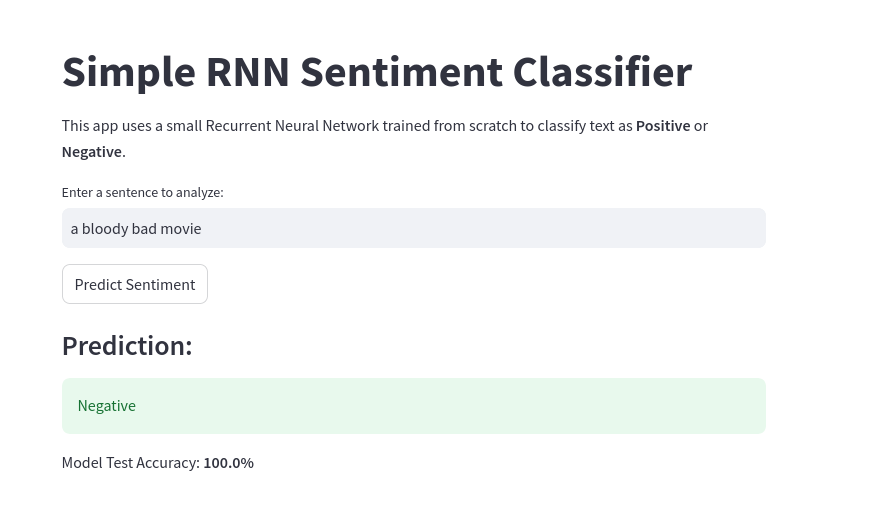

### How to Use This Sentiment Analysis App

1. **Run the notebook code** to start the Streamlit app: run the below cell 
2. **Open the provided browser URL** (e.g., `http://localhost:8501`) to see the app interface like in the screenshot.
3. Enter a sentence in the input box and click the **"Predict Sentiment"** button.
4. **Watch the Jupyter notebook output** while the model runs you will see a progress bar showing the training or prediction process in real-time.
5. The prediction result will immediately appear on the Streamlit page in your browser.

This way you get a **hands-on experience** by observing the model’s inner workings in the notebook (progress bar, accuracy) while interacting smoothly with the app’s GUI in the browser.

In [ ]:
# !streamlit run EnhancedRNNSentimentAnalysis.py 

SyntaxError: invalid syntax (4102172471.py, line 1)

### Individual Task: Refactor and Extend the Sentiment Classifier

You are required to individually refactor the existing sentiment analysis code to add a **neutral** class, turning it into a multi-class classification problem.

Your task includes:

1. Modifying the dataset and labels to include `Neutral` examples.
2. Updating the model output layer and training to handle three classes.
3. Adjusting evaluation and prediction code accordingly.
4. Testing your extended model and reporting the results.

This will help you practice multi-class classification and deepen your understanding of neural network modifications which is a foundational step paving the way for advanced techniques like transfer learning.

Please submit your completed work as a Jupyter Notebook at the end of the day.

#### /!\

An *important technical detail* when working with tokenizers in language models such as GPT-2, Qwen, etc.

When the author says:

> “Check the token IDs for the words ' positive' and ' negative'
>
> (note the space before the words)”

they are emphasizing **the space before the words** (`" positive"` instead of `"positive"`) because **tokenizers used in most transformer language models are *subword* tokenizers that treat leading spaces as part of the token**.

Here’s what that means in practice:

* These models were trained on raw text where words are separated by spaces.
* Instead of representing each word separately, the tokenizer splits text into smaller pieces (“tokens”).
* For efficiency, most tokenizers learn that `" positive"` (a space followed by “positive”) is a *common* sequence — it becomes a *single token*.
* However, `"positive"` (without the space) might *not* exist as a token by itself — it could instead be split into smaller parts like `["pos", "itive"]`.

So if you want to compare how likely the model is to generate “ positive” vs “ negative” **after some text**, you must include the space — because that’s what the model would actually generate next.

If you omitted the space, the token IDs would not correspond to the true next-token candidates, and your results would be meaningless or misleading.

✅ **In short:**

* `" positive"` = the model’s true next-token candidate after text.
* `"positive"` = a different tokenization, not what would actually appear next.

**Example:**

```python
tokenizer.encode(" positive")  # likely gives [6785]
tokenizer.encode("positive")   # might give [1234, 5678] (split into multiple tokens)
```

So the author’s emphasis on *the space before the word* is a crucial technical point to ensure correct tokenization and meaningful probability comparisons.


#### 1. Modify the dataset and labels to include `Neutral` examples

In [27]:
train_X = [
    # Positive examples
    'good', 'happy', 'very good', 'very happy', 'i am happy', 'this is good',
    'i am good not bad', 'this is good not bad', 'i am good and happy',
    'i am good right now', 'i was good earlier', 'i was happy earlier',
    'this is very good right now', 'this was very good earlier', 'this was very happy earlier',
    'i was good and not bad earlier',

    # Negative examples
    'bad', 'sad', 'not good', 'not happy', 'very bad', 'very sad', 'i am bad',
    'this is bad', 'i am sad', 'this is sad', 'i am not happy', 'this is not good',
    'i am very bad', 'this is very bad', 'this is very sad', 'i am bad right now',
    'this is bad right now', 'i was bad earlier', 'this was bad earlier',
    'this was very bad earlier', 'this was very sad earlier',
    'i was not good and not happy earlier', 'i am not at all good or happy right now',

    # Neutral examples (new)
    'okay', 'fine', 'not bad not good', 'this is okay', 'i am fine', 'this is neither good nor bad',
    'i am neither happy nor sad', 'this is just alright', 'i am alright right now',
    'this is not good but not bad', 'this is not happy but not sad',
    'i am not at all sad or happy', 'this is not at all good or bad',
    'this was okay earlier', 'i was fine earlier'
]

train_y = [
    # Positive labels (1)
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

    # Negative labels (0)
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

    # Neutral labels (2)
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
]

test_X = [
    # Positive examples
    'this is happy', 'i am good', 'i am very good', 'this is good and happy',
    'this is good right now', 'i was good earlier',

    # Negative examples
    'this is not happy', 'i am not good', 'this is not bad', 'i am not sad',
    'i am very sad', 'this is bad not good', 'i am not good and not happy',
    'this is not at all good', 'this is sad right now', 'this is very bad right now',

    # Neutral examples (new)
    'this is okay', 'i am fine', 'this is neither good nor bad',
    'this is not good but not bad', 'this is not happy but not sad',
    'this was okay earlier', 'i was fine earlier'
]

test_y = [
    # Positive labels (1)
    1, 1, 1, 1, 1, 1,

    # Negative labels (0)
    0, 0, 1, 1, 0, 0, 0, 0, 0, 0,

    # Neutral labels (2)
    2, 2, 2, 2, 2, 2, 2
]

In [33]:
vocab = set([word for text in train_X for word in text.split()])
vocab.add("<UNK>")
vocab_size = len(vocab)
print(vocab_size)

26


In [34]:
word_to_index = {w:i for i, w in enumerate(vocab)}
print(word_to_index)

{'am': 0, 'at': 1, 'this': 2, 'i': 3, 'happy': 4, 'bad': 5, 'right': 6, 'not': 7, 'just': 8, 'alright': 9, 'was': 10, 'okay': 11, 'good': 12, 'all': 13, 'but': 14, 'fine': 15, 'now': 16, 'or': 17, 'earlier': 18, 'is': 19, 'neither': 20, 'nor': 21, 'very': 22, 'sad': 23, '<UNK>': 24, 'and': 25}


#### 2. Update the model output layer and training to handle three classes

In [30]:
def initWeights(input_size, output_size):
    return np.random.uniform(-1, 1, (input_size, output_size)) * np.sqrt(6 / (input_size + output_size))

def softmax(x):
    exp = np.exp(x - np.max(x))
    return exp / np.sum(exp)

def tanh(x, derivative=False):
    if derivative:
        return 1 - (x ** 2)
    return np.tanh(x)

In [ ]:
class RNN:
    def __init__(self, input_size, hidden_size, output_size, num_epochs, learning_rate):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        # Network
        self.w1 = initWeights(input_size, hidden_size)
        self.w2 = initWeights(hidden_size, hidden_size)
        self.w3 = initWeights(hidden_size, output_size)  # Output size is now 3
        self.b2 = np.zeros((1, hidden_size))
        self.b3 = np.zeros((1, output_size))  # Bias for 3 classes

    def forward(self, inputs):
        self.hidden_states = [np.zeros_like(self.b2)]
        for x in inputs:
            layer1 = np.dot(x, self.w1)
            layer2 = np.dot(self.hidden_states[-1], self.w2) + self.b2
            self.hidden_states.append(tanh(layer1 + layer2))
        return np.dot(self.hidden_states[-1], self.w3) + self.b3

    def backward(self, error, inputs):
        d_b3 = error
        d_w3 = np.dot(self.hidden_states[-1].T, error)
        d_b2 = np.zeros_like(self.b2)
        d_w2 = np.zeros_like(self.w2)
        d_w1 = np.zeros_like(self.w1)
        d_hidden = np.dot(error, self.w3.T)
        for t in reversed(range(len(inputs))):
            d_hidden *= tanh(self.hidden_states[t + 1], derivative=True)
            d_b2 += d_hidden
            d_w2 += np.dot(self.hidden_states[t].T, d_hidden)
            d_w1 += np.dot(inputs[t].T, d_hidden)
            d_hidden = np.dot(d_hidden, self.w2)
        for grad in (d_b3, d_w3, d_b2, d_w2, d_w1):
            np.clip(grad, -1, 1, out=grad)
        self.b3 += self.learning_rate * d_b3
        self.w3 += self.learning_rate * d_w3
        self.b2 += self.learning_rate * d_b2
        self.w2 += self.learning_rate * d_w2
        self.w1 += self.learning_rate * d_w1

    def train(self, X, y):
        for _ in tqdm(range(self.num_epochs)):
            for text, label in zip(X, y):
                inputs = oneHotEncode(text)
                pred = self.forward(inputs)
                error = -softmax(pred)
                error[0][label] += 1  # Label can now be 0, 1, or 2
                self.backward(error, inputs)

    def test(self, X, y):
        correct = 0
        for text, label in zip(X, y):
            inputs = oneHotEncode(text)
            pred = self.forward(inputs)
            prediction = np.argmax(pred)
            print(text, "=>", ["Négative", "Positive", "Neutre"][prediction])
            if prediction == label:
                correct += 1
        print(f"Accuracy: {round(100 * correct / len(X), 2)}%")

In [42]:
rnn = RNN(input_size=vocab_size, hidden_size=64, output_size=3, learning_rate=0.02, num_epochs=1000)
rnn.train(train_X, train_y)

100%|██████████| 1000/1000 [00:05<00:00, 171.17it/s]


#### 3. Adjuste evaluation and prediction code accordingly

#### 4. Test your extended model and reporting the results

In [43]:
rnn.test(test_X, test_y)

this is happy => Positive
i am good => Positive
i am very good => Positive
this is good and happy => Positive
this is good right now => Positive
i was good earlier => Positive
this is not happy => Négative
i am not good => Négative
this is not bad => Négative
i am not sad => Négative
i am very sad => Négative
this is bad not good => Négative
i am not good and not happy => Négative
this is not at all good => Neutre
this is sad right now => Négative
this is very bad right now => Neutre
this is okay => Neutre
i am fine => Neutre
this is neither good nor bad => Neutre
this is not good but not bad => Neutre
this is not happy but not sad => Neutre
this was okay earlier => Neutre
i was fine earlier => Neutre
Accuracy: 82.61%


---

# Part II: Sentiment Analysis With pre-trained Langauge Model

### **Why Move from RNNs to Transformer-Based Language Models for Sentiment Analysis**

In **Part I**, we used a **Vanilla RNN** to perform sentiment analysis on movie reviews. RNNs process text one token at a time, maintaining a “hidden state” that carries contextual information from earlier words to later ones. This sequential design gives RNNs a strong intuition about order and structure in language but it also introduces key limitations.

As the length of a movie review grows, an RNN often struggles to retain early information. Imagine a review that begins with *"Although the movie started slowly, the ending was absolutely brilliant"* An RNN might lose the initial contrastive cue ("although...") by the time it reaches the conclusion leading to an incorrect prediction of negative sentiment. Long-range dependencies like this are common in natural language and difficult for RNNs to capture reliably due to vanishing gradients and limited memory capacity.

**Transformer-based language models** overcome these issues through a mechanism called **self-attention** which allows the model to "look" at all parts of a text simultaneously rather than step-by-step. This means the model can directly connect *"although"* to *"brilliant"* even if they are far apart in the sequence. Transformer-based language models handle these long contexts far better. They can retain the relationship between distant parts of a review and produce more accurate sentiment predictions. Beyond improved performance, transformers also offer advantages such as efficient parallelization during training, scalability to large datasets and strong generalization through pretraining. These properties make them an excellent choice for sentiment classification and are the reason we are moving from a vanilla RNN implementation to a language model–based approach in our practical session. Pretrained language models like **DistilBERT**, **GPT2** or small open-source models (e.g., Qwen, Huggingface SmolLM) have already learned rich linguistic patterns from massive text corpora. We can reuse that knowledge to classify movie reviews without training from scratch saving both time and computational resources.

In this session, we will explore this transition in practice by applying a **small transformer-based language model** and see firsthand how self-attention and pretraining improve accuracy and generalization. This shift from RNNs to transformer-based LMs represents a broader evolution in how modern NLP systems *shifted* from RNN-based archtiecture to transformers-based architecture.

### Using a Small Language Model for Zero-Shot Sentiment Analysis

Generating language is one of the most fascinating applications of transformer-based models, like in our daily life when we are using ChatGPT. To predict the next token accurately, a language model must implicitly learn a great deal about the structure and meaning of language and even about the world itself. We can take advantage of this ability to perform various tasks without explicit task-specific training.

For example, instead of training a dedicated sentiment classifier  we can **prompt a pre-trained language model** with a question like:

> *Is the following review positive or negative about the movie?*
> *[Insert movie review text here]*

This demonstrates how a sufficiently powerful language model can perform tasks it was **never explicitly trained for** a property known as **zero-shot generalization**. The more powerful the model the wider the range of tasks it can handle without additional training.

To see this in action, we will use a **small language model** such as **Qwen/Qwen2-0.5B** as a sentiment classifier.

We will use a **zero-shot** approach to make the exercise more interesting. This means:

* We won’t train on labeled data.
* Instead, we will prompt the model directly with the review text and ask it to predict the sentiment.

There are multiple ways to use a **generative language model** as a classifier. The simplest is to create a *prompt template* that instructs the model to respond with only `"positive"` or `"negative"`.
An alternative approach which is useful with smaller models is to inspect the model's **next-token probabilities** and compare which token (e.g. `" positive"` or `" negative"`) the model assigns a higher likelihood.

We qill adopt this latter approach in our practical exercise.

### **Playground — Download a Small Language Model and Generate Text**

Before using our small language model for sentiment classification, let first experiment with it in a **text generation playground**. This helps us understand how transformer-based models predict the next token based on context.

#### **Objective**

Download a small pre-trained language model (e.g., **Qwen**, **GPT-2**, or **DistilGPT-2**) and generate a few sentences of text. This will help you get familiar with the model’s generative behavior before we adapt it for classification.

#### **Instructions**

1. **Install and import dependencies:**

   ```python
   !pip install transformers torch
   from transformers import AutoModelForCausalLM, AutoTokenizer
   import torch
   ```

2. **Load a small model and its tokenizer:**

3. **Create a short prompt and generate text:**

4. **Observe the output.**

   * Does the model continue the text logically?
   * How coherent or creative is it?


Even though this model wasn't explicitly trained for *sentiment analysis* it has learned enough about language and context from pretraining to generate fluent, contextually relevant sentences. This generative capability is the foundation we'll build upon in the next step—using the same model architecture to classify sentiment instead of generating free-form text.


In [44]:
# Step 1 donwload the model
from transformers import AutoTokenizer

# Use the id of the model you want to use
# GPT-2 "openai-community/gpt2" 137M
# Qwen "Qwen/Qwen2-0.5B" 494M
# SmolLM "HuggingFaceTB/SmolLM-135M"

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")

tokenizer_config.json: 0.00B [00:00, ?B/s]

c:\Users\auria\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\auria\.cache\huggingface\hub\models--Qwen--Qwen2-0.5B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Defines the text `prompt` you wil feed into the `tokenizer` insert wthatever you want here you can try different models (GPT-2, Qwen, or SmolLM). Each model has its own tokenizer and vocabulary, so token IDs may differ.

In [45]:
prompt = "I don't know if I should accept or not"

input_ids = tokenizer(prompt).input_ids  # The tokenizer processes the input text and converts it into a list of token IDs
input_ids

[40, 1513, 944, 1414, 421, 358, 1265, 4193, 476, 537]

These numbers are what the model actually `**sees**` as input.

In [46]:
for t in input_ids:
    print(t, "\t:", tokenizer.decode(t))

40 	: I
1513 	:  don
944 	: 't
1414 	:  know
421 	:  if
358 	:  I
1265 	:  should
4193 	:  accept
476 	:  or
537 	:  not


This loop prints each token ID and its decoded text so you can see how the model splits the phrase into subword units (i.e. tokens). Each corresponding text fragment (e.g., `" don"`, `" know"`) shows how the tokenizer breaks your sentence into tokens.

Notice a few interesting things:

1. **Leading spaces matter.**
   Most tokens (like `" don"`, `" know"`, `" if"`, `" should"`) include a *space before the word*.
   That's because the tokenizer was trained on natural text with spaces, and it learns that `" don"` (space + 'don') is a more common pattern than `"don"` by itself.
   This is why, when comparing tokens like `" positive"` vs `"negative"`, we emphasize including the leading space.

2. **Subword tokenization.**
   The contraction `"don't"` is split into two tokens:

   * `" don"`
   * `"'t"`
     This shows the **subword tokenization strategy** rather than memorizing every word form, the tokenizer breaks rare or inflected words into smaller known chunks.
     This allows the model to handle unseen words by combining familiar subwords.

3. **Consistent vocabulary usage.**
   Common words like `"I"`, `"if"`, `"or"`, `"not"` appear as single tokens because they are frequent and stored whole in the vocabulary.


This Demonstrates that language models don't process raw text they process token IDs. Tokenization is **model-specific** different models may split the same text differently. Subword tokenization helps the model handle any word even unseen ones (OOV) by composing them from smaller known pieces.

In short: this code shows how natural text is transformed into the numerical form that a language model like Qwen can understand and generate from.

### Predicting Probabilities
[GPT-2](https://huggingface.co/docs/transformers/model_doc/gpt2), [Qwen](https://huggingface.co/Qwen/Qwen2-0.5B) and [SmolLM](https://huggingface.co/HuggingFaceTB/SmolLM-360M) are [causal (autoregressive)](https://huggingface.co/docs/transformers/tasks/language_modeling) language models trained to predict the next token given previous tokens. The [Hugging Face transformers](https://huggingface.co/docs/transformers/index) library makes it easy to generate text or explore the model predictions. Let's start by loading the model:

In [47]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [48]:
prompt = "I don't know if I should accept or not"

input_ids = tokenizer(prompt, return_tensors="pt").input_ids #etape1
outputs = model(input_ids) #etape2
outputs.logits.shape # An output for each input token

torch.Size([1, 10, 151936])

First, we **tokenize the prompt** since the language model only understands tokens not raw text. Next, we feed the tokenized input to the model to get the **logits**, the raw predictions for each token.

The output has 3 dimensions:

1. **Batch size** 1, because we processed a single sequence. Typically it is a batch of sentences.
2. **Sequence length** the number of input tokens (10 in this example).
3. **Vocabulary size** the number of possible tokens the model can predict (≈151,936 here). This is actually the Vocabulary size of the Qwen model.

For each input token, the model outputs a **logit vector** containing a score for every token in its vocabulary. These logits represent how likely each token is to follow the sequence so far. For our example sentence:

```
"I don't know if I should accept or not"
```

the model predicts logits for `"I"`, `"I don't"`, `"I don't know"`, and so on.

We can use these logits to select the **most probable next token** or convert them to **probabilities** for more flexible tasks like sampling.

Let's focus on the logits for the entire prompt to see how the model predicts the next word. We can find the most likely next token by applying argmax() to the logits:

In [49]:
final_logits = model(input_ids).logits[0, -1] # The last set of logits
final_logits.argmax() # The position of the maximum

tensor(13)

Here, `tensor(13)` is the token ID that the model predicts as the most probable continuation of the input sequence: "**I don't know if I should accept or not**"

Decoding this token reveals the model’s prediction:

In [50]:
tokenizer.decode(final_logits.argmax())

'.'

The model predicts a period `**(.)**` showing it has learned typical story structures after an opening like "It was a dark and stormy" a sentence often ends or transitions, reflecting common narrative patterns in its training data.

We can explore **other likely continuations** of the sequence by selecting the **top 10 logits** using `topk()`. This gives us the tokens the model considers most probable after our prompt.

In [51]:
import torch
top10_logits = torch.topk(final_logits, 10)
for index in top10_logits.indices:
    print(tokenizer.decode(index))

.
,
 this
.

 the
.


?
 but


 my


Output:

```
.
,
 this
.
 the
.
?
 but
 my
```

**Explanation:**

* Each token here corresponds to a **plausible next word or punctuation** following `"I don't know if I should accept or not"`.
* The model predicts common sentence continuations based on patterns it learned during training.
* For example, `.` and `,` appear multiple times because the model often ends or continues sentences in similar contexts.
* Words like `"this"`, `"the"`, `"but"`, and `"my"` represent alternative ways the story could continue.

This demonstrates that the model **doesn't just pick one token** but assigns probabilities to many possible next tokens, which allows for flexible text generation.

To understand **how confident the model is** about each possible next token, we convert the logits into **probabilities** using the **softmax** function. Softmax normalizes the logits so they sum to 1 giving a proper probability distribution over the vocabulary (`≈151,936` using `Qwen/Qwen2-0.5B`).

The following code computes the **top 10 most likely tokens** and their probabilities:

In [52]:
k=10
top10 = torch.topk(final_logits.softmax(dim=0), k)
for value, index in zip(top10.values, top10.indices):
    print(f"{tokenizer.decode(index):<10} {value.item():.2%}")

.          21.41%
,          11.59%
 this      10.25%
.
         6.37%
 the       6.08%
.

        2.14%
?          2.06%
 but       1.95%

          1.82%
 my        1.68%


Output:

```
.          21.41%
,          11.59%
this       10.25%
.           6.37%
the         6.08%
.           2.14%
?           2.06%
but         1.95%
            1.82%
my          1.68%
```

**Key points:**

* The **probabilities** tell us how likely the model thinks each token is to follow the prompt:
  `"I don't know if I should accept or not"`.
* For example, the period (`.`) has the highest probability (21.41%), meaning the model strongly expects the sentence to end or pause.
* Other tokens like `,`, `this`, or `but` are also plausible continuations, but with lower probabilities.
* This probabilistic view helps in tasks like **text generation**, where we might sample from these probabilities instead of always picking the single most likely token.

### **Try It Yourself: Exploring Model Predictions**

Before moving on, experiment with the code above. Here are some ideas to get you started:

1. **Change `K` in `topk()`**

   * Instead of the top 10 tokens, try `top15` or `top20`.
   * How do additional candidates change the set of possible next words?

2. **Modify words in the prompt**

   * Replace key words like `"accept"` or `"not"` with alternatives, e.g., `"join"`, `"decline"`, `"agree"`, `"refuse"`.
   * Observe how the model’s **top predictions and probabilities** change.
   Does the model still predict a similar continuation, or does it adapt to the new context?

3. **Try different input strings**

   * Use completely new sentences.
   * Do you agree with the model's predictions? How confident does it seem?

4. **Test grammar**

   * Provide ungrammatical or incomplete sequences.
   * How does the model handle them? Check the top probabilities does it try to **fix** the sentence or suggest unlikely continuations?

These experiments help you **understand how the model interprets context, grammar and word choice** and illustrate the probabilistic nature of language modeling.

### **Generating Text**

Once we understand how to get a model's predictions for the next token, generating text becomes straightforward. We can repeatedly feed the model's predictions back into itself: call `model(input_ids)`, select a new token, append it to the input and repeat.

Transformers autoregressive models simplify this process with the **`generate()`** method, which handles multiple forward passes and token selection automatically. Here's an example:

In [53]:
output_ids = model.generate(input_ids, max_new_tokens=20)
decoded_text = tokenizer.decode(output_ids[0])
print("Input IDs", input_ids[0])
print("Output IDs", output_ids)
print(f"Generated text: {decoded_text}") 

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Input IDs tensor([  40, 1513,  944, 1414,  421,  358, 1265, 4193,  476,  537])
Output IDs tensor([[  40, 1513,  944, 1414,  421,  358, 1265, 4193,  476,  537,   13,  358,
         2776,  537, 2704,  421,  358, 1265, 4193,  476,  537,   13,  358, 2776,
          537, 2704,  421,  358, 1265, 4193]])
Generated text: I don't know if I should accept or not. I'm not sure if I should accept or not. I'm not sure if I should accept


**How it works:**

* Previously, calling `model()` returned logits for every token in the vocabulary (e.g., 151,936). We had to convert logits to probabilities and pick the next token manually.
* The `generate()` method **automates this process**: it predicts the next token, appends it to the input sequence, and repeats until the desired number of tokens is generated or an end-of-sequence token.
* The method returns the **token IDs of the full sequence** (original input + new tokens), which we can decode back into readable text using `tokenizer.decode()`.

There are many strategies for generation, such as **greedy decoding, sampling, or top-k/top-p sampling**, which control how the model selects the next token and affect the creativity and diversity of the generated text.

Here’s a concise way to mention the warning and repetition without diving into solutions yet:

#### **Note on Warnings and Repetition**

When running the text generation code, you may notice a **warning** like:

```
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id` for open-end generation.
```

Additionally, the **generated text may contain repeated sentences**, for example:

```
I don't know if I should accept or not. I'm not sure if I should accept or not. I'm not sure if I should accept
```

We will **explain the reasons for these warnings and the repetition** along with strategies to reduce or fix them.


#### 1. **The Warning**

The warnings you see:

```
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.
Setting pad_token_id to eos_token_id
```

mean:

* **Attention mask missing:** The model doesn’t know which tokens are "real" input and which are padding. Without it, the model might treat parts of the input incorrectly when generating.
* **Pad token defaulted to EOS:** Since your tokenizer has no pad token `generate()` uses the `EOS` token as padding. This can confuse the model, especially during auto-regressive generation because the model may think the sequence hasn't ended properly.

#### 2. **Why the repetition happens**

The output:

```
I don't know if I should accept or not. I'm not sure if I should accept or not. I'm not sure if I should accept
```

shows repeated sentences because:

1. **No attention mask and pad token confusion** the model may not know where the sequence ends properly.
2. **Default generation settings** `max_new_tokens=20` doesn't prevent repetition and the model's default decoding method (`greedy` or `beam search`) may favor repeating familiar phrases.
3. **Deterministic decoding** if you use greedy decoding (the default) the model can get stuck repeating the most likely next token.

### 3. **How to fix it**


In [54]:
attention_mask = torch.ones_like(input_ids) #step 1 set attention mask:
model.config.pad_token_id = tokenizer.eos_token_id #step 2 set pad token explicitly:

output_ids = model.generate(
    input_ids,
    attention_mask=attention_mask,
    max_new_tokens=20,
    do_sample=True,     # enables sampling so the model can pick the next token probabilistically instead of always choosing the most likely one
    top_k=50,           # sample from top 50 tokens only consider the 50 most likely tokens at each step when sampling ignoring the rest
    top_p=0.95,         # also called nucleus sampling pick tokens from the smallest set whose cumulative probability is 95%. This adds diversity while avoiding extremely unlikely words.
    temperature=0.8,    # controls randomness lower values (<1) make the model more confident and conservative higher values (>1) make it more creative and random.
)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


In [55]:
decoded_text = tokenizer.decode(output_ids[0])
print("Input IDs", input_ids[0])#the input IDs are the numerical tokens for your prompt
print("Output IDs", output_ids)#the output IDs include both the input and the model-generated tokens
print(f"Generated text: {decoded_text}") #don’t forget to decode the output_ids using the tokenizer to get human-readable text.

Input IDs tensor([  40, 1513,  944, 1414,  421,  358, 1265, 4193,  476,  537])
Output IDs tensor([[  40, 1513,  944, 1414,  421,  358, 1265, 4193,  476,  537,   11,  323,
          358, 2776,  537, 2704, 3425,  432,  374, 5802,  432,  311,  653,  432,
           13,  358, 1366,  311, 1779,  421]])
Generated text: I don't know if I should accept or not, and I'm not sure whether it is worth it to do it. I want to check if


---

## Zero-Shot Classification with Generative Models
Now that we understand how to generate text using a generative model, we can move on to classification. This section shows how to use a pre-trained generative model for classification without training. We will work with a dataset of labeled reviews and evaluate performance using a confusion matrix. A [confusion matrix](https://www.evidentlyai.com/classification-metrics/confusion-matrix) is a table that summarizes a model's predictions by showing the number of true positives, true negatives, false positives and false negatives. The rows represent the actual classes (ground truth) while the columns represent the predicted classes. Analyzing this matrix reveals the model's strengths and weaknesses in distinguishing between specific classes.

In [56]:
# from genaibook.core import get_device
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

In [67]:
tokenizer.encode(" positive"), tokenizer.encode(" negative"), tokenizer.encode("positive"), tokenizer.encode("negative")

([6785], [8225], [30487], [42224])

Yyou get **token IDs** for the words with the **leading space**. For example:

* `" positive"` → `id = 6785`
* `" negative"` → `id = 8225`

Note the space matters:

* `"positive"` (no space) → `id = 30487`
* `"negative"` (no space) → some other ID

This happens because most tokenizers are **subword-based**. They distinguish between a word that starts a sentence (no leading space) and a word in the middle of a sentence (with a leading space).

So in the following `score` function, we compare the logits for `" positive"` and `" negative"` because the prompt puts these words **after “Answer:”**, which treats them as continuation tokens, not sentence-start tokens.

In [ ]:
def score(sample, prompt_template):
    """
    Predict whether a review is positive or negative using a generative model with a custom prompt.

    Parameters:
    -----------
    sample : dict
        A dictionary containing at least the key 'text' with the review text.
    prompt_template : str
        A template string for the prompt, where the review text will be inserted.
        Example: "Question: Is the following review positive or negative about the movie?\nReview: {review} Answer:"

    Returns:
    --------
    dict
        The input sample dictionary updated with a new key 'pred':
        - 1 if predicted positive
        - 0 if predicted negative
    """
    # Fill in the prompt template with the review text
    prompt = prompt_template.format(review=sample['text'])

    # Tokenize the prompt
    input_ids = tokenizer(prompt, truncation=True, return_tensors="pt").input_ids

    # Get logits from the model
    final_logits = model(input_ids).logits[0, -1]

    # Assign prediction based on token logits
    sample["pred"] = 1 if final_logits[6785] > final_logits[8225] else 0

    return sample

In the `score` function:

* we use 1 (`positive`) and 0 (`negative`),
* we receive a sample so we can use the `datasets` library. You can use this as a dictionary with the review being accessible with `sample["text"]`,
* we add a column, `pred`, which contains the 0 or 1 from the model.
* we add `truncation=True` to the `tokenizer` call. Truncation is needed as `score` will be called with a batch of samples and we need to ensure that all samples have the same length.
    * **`truncation=True`** ensures that any review longer than the model can handle gets **cut down to the maximum allowed length**.
    * Without truncation, very long reviews could **cause errors** or **produce inconsistent input lengths**, which can break batch processing.
    * By truncating, all inputs fed to the model have a **uniform length** which is important when processing multiple samples at once using batches (like with the `datasets` library).

In [59]:
sample_review = {"text": "This movie was terrible!"}
prompt_template = "Question: Is the following review positive or negative about the movie?\nReview: {review} Answer:"

score(sample_review, prompt_template)

{'text': 'This movie was terrible!', 'pred': 0}

Now let's use the [IMDB](https://huggingface.co/datasets/imdb) dataset, which contains 25,000 rows of labeled reviews.  We'll use the [datasets](https://huggingface.co/docs/datasets/index) library to load the dataset and load the `train` split.

In [60]:
from datasets import load_dataset

dataset = load_dataset("imdb")["train"]

README.md: 0.00B [00:00, ?B/s]

c:\Users\auria\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\auria\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTT

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

For fast iteration, we will just use 100 random samples from the dataset. We will `shuffle` the dataset and then take the first 100 samples.

In [61]:
shuffled_dataset = dataset.shuffle(seed=42)
small_dataset = shuffled_dataset.select(range(100))
small_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 100
})

Then, we can use the `score` function to predict the sentiment of the reviews and compare the predictions with the actual labels.

In [62]:
prompt_template = "Question: Is the following review positive or negative about the movie?\nReview: {review} Answer:"

updated_dataset = small_dataset.map(score,fn_kwargs={"prompt_template": prompt_template})
updated_dataset

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'pred'],
    num_rows: 100
})

We will use the [evaluate](https://huggingface.co/docs/evaluate/index) library to generate a **confusion matrix**. It shows the counts of **true positives, true negatives, false positives, and false negatives**. Rows represent the actual (label) classes while columns represent the predicted classes. Examining this matrix helps reveal the model’s strengths and weaknesses in distinguishing between classes.

In [64]:
import evaluate

confusion_matrix = evaluate.load("confusion_matrix")
cm = confusion_matrix.compute(
    references=updated_dataset["label"],
    predictions=updated_dataset["pred"],
)
cm

{'confusion_matrix': array([[53,  0],
        [18, 29]], dtype=int64)}

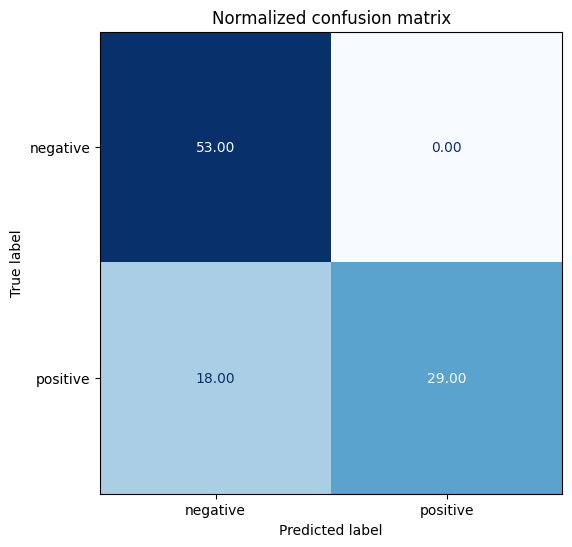

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm["confusion_matrix"],
    display_labels=["negative", "positive"],
)
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)

plt.title("Normalized confusion matrix")
plt.show()

#### What this means:

* **True Negative (TN): 53**
  The model correctly predicted 53 reviews as negative when they actually were negative.

* **False Positive (FP): 0**
  The model did not mistakenly predict any negative reviews as positive **no false positives**.

* **False Negative (FN): 18**
  The model incorrectly predicted 18 positive reviews as negative Zthese are missed positives.

* **True Positive (TP): 29**
  The model correctly predicted 29 reviews as positive.

#### Interpretation:

* The model is **very accurate at identifying negative reviews** (53 correct negatives, 0 false positives). It rarely mistakes a negative review for positive.

* However, the model **misses a significant number of positive reviews** (18 false negatives), labeling them incorrectly as negative.

* The **true positives (29)** are lower compared to true negatives (53), suggesting the model is somewhat biased or less sensitive towards positive reviews.

* This indicates the model has **high precision for the negative class** but **lower recall for the positive class** (since it misses many positives).


The model is **conservative in calling a review positive** favoring the negative class and thus resulting in many missed positive cases. This kind of confusion matrix often reflects a model with high specificity (true negative rate) but lower sensitivity (true positive rate).

Finally, we can also convert the dataset to a Pandas `DataFrame` and explore the data directly. Here is a starting point

In [66]:
df = updated_dataset.to_pandas()
df.head()

,text,label,pred
0,There is no relation at all between Fortier an...,1,0
1,This movie is a great. The plot is very true t...,1,1
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",0,0
3,In the process of trying to establish the audi...,1,0
4,"Yeh, I know -- you're quivering with excitemen...",0,0


### Individual task : add the neutral sentiment

1. Add or source examples of **neutral sentiment**.
2. Update the prompt and scoring function to handle three classes.
3. Test the updated model on the new dataset and report results.

In [105]:
# I chose a dataset that contains tweet with the associated sentiment (negative, neutral, positive)
dataset = load_dataset("tweet_eval", "sentiment")
print(dataset["train"].features)
print(dataset["train"][0])

{'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}
{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}


In [104]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

def score(sample, prompt_template):
    """
    Predict whether a review is positive, negative, or neutral using a generative model with a custom prompt.
    """
    prompt = prompt_template.format(review=sample['text'])
    input_ids = tokenizer(prompt, truncation=True, return_tensors="pt").input_ids
    final_logits = model(input_ids).logits[0, -1]

    # Get the logits for the tokens corresponding to "positive", "negative", and "neutral"
    # You need to find the token IDs for these words in the tokenizer's vocabulary
    pos_id = tokenizer.encode(" positive")
    neg_id = tokenizer.encode(" negative")
    neu_id = tokenizer.encode(" neutral")

    # Assign prediction based on the highest logit
    if final_logits[pos_id] > final_logits[neg_id] and final_logits[pos_id] > final_logits[neu_id]:
        sample["pred"] = 2  # positive
    elif final_logits[neg_id] > final_logits[pos_id] and final_logits[neg_id] > final_logits[neu_id]:
        sample["pred"] = 0  # negative
    else:
        sample["pred"] = 1  # neutral

    return sample

In [ ]:
prompt_template = """
Question: Is the following tweet positive, negative, or neutral?
Tweet: {review}
Answer with one word: positive, negative, or neutral.
"""

In [99]:
# Select a small subset for testing
small_dataset = dataset["train"].shuffle(seed=42).select(range(100))

# Apply the scoring function
updated_dataset = small_dataset.map(score, fn_kwargs={"prompt_template": prompt_template})

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

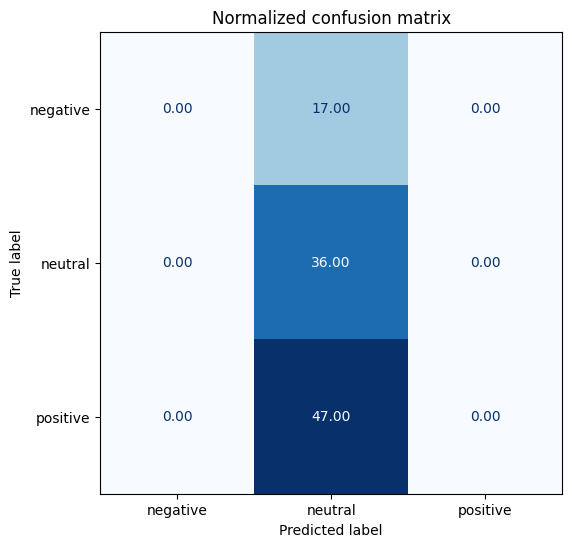

In [100]:
import evaluate
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Load the confusion matrix metric
confusion_matrix = evaluate.load("confusion_matrix")

# Compute the confusion matrix
cm = confusion_matrix.compute(
    references=updated_dataset["label"],
    predictions=updated_dataset["pred"],
)

# Afficher la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm["confusion_matrix"],
    display_labels=["negative", "neutral", "positive"],
)
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalized confusion matrix")
plt.show()

In [74]:
df = updated_dataset.to_pandas()
print(df.head())

                                                text  label  pred
0  Few more hours to iPhone 6s launch and im stil...      2     1
1  Last night we were named NZ's 27th fastest gro...      2     1
2  All the hoes will be out this Saturday at the ...      0     1
3  BUENOS AIRES--Argentina late Wednesday approve...      1     1
4  "Every time I see a runner slide into 1st, I s...      0     1


I tried several score function but the prediction is always the same, it always predict the tweet as neutral. I tried various way of writing the function but the only change I could have was that the prections was all positives, and I don't arrive to modify this

---
# **Part III: Sentiment Analysis with TensorFlow**

In this part, you will open the ``Google_text_classification.ipynb`` notebook and complete it.

The notebook guides you through training a **sentiment analysis model** that classifies movie reviews as **positive** or **negative** based on the review text. This is an example of **binary classification** a fundamental and widely applicable machine learning task.

You will work with the **Large Movie Review Dataset** which contains **50,000 IMDB movie reviews** split evenly into **25,000 for training** and **25,000 for testing**. Both sets are **balanced**, containing an equal number of positive and negative reviews, allowing you to focus on building and evaluating your model effectively.


---

# Part IV – Extend the Model (Deliverable)

In this final part, each student will **submit a completed Jupyter Notebook on Moodle**. The deliverable should demonstrate how you can extend the models from previous parts to handle more complex classification tasks. **The submission deadline is one week after the end of the practical session.**

### Objectives

**Parts I & II:**

* Modify the **RNN** and the **small language model** to include a third sentiment class: **neutral**, in addition to positive and negative.

**Part III:**

* Adapt the **TensorFlow Keras model**, originally trained as a binary classifier on the IMDB dataset, to handle **multi-class classification**. Specifically, train the model to predict the **tag of a programming question** from the Stack Overflow dataset.

### Tasks by Part

**Part I – RNN-based model:**

* Extend the dataset to include the **Neutral** sentiment.
* Update the model's output layer and training process for **three classes**.
* Adjust evaluation and prediction code to account for the new class.
* Test your extended model and report results.

**Part II – Small Language Model:**

* Add or source examples of **neutral sentiment**.
* Update the prompt and scoring function to handle three classes.
* Test the updated model on the new dataset and report results.

**Part III – TensorFlow Keras model:**

* Download and prepare the [Stack Overflow dataset](https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz), which contains 16,000 programming questions across four languages: **Python, CSharp, Java, JavaScript**. Each question is labeled with exactly one tag.
* Modify the notebook you built for IMDB to:

  1. Replace the IMDB dataset with the Stack Overflow dataset.
  2. Change the output layer to `Dense(4)` to reflect the four classes.
  3. Use `SparseCategoricalCrossentropy(from_logits=True)` as the loss function and `accuracy` as the metric.
  4. Update plots to use `accuracy` and `val_accuracy`.
* Train the model to predict the correct tag for each question, despite keywords like the programming language being replaced with the word **`BLANK`** to increase difficulty. In the Stack Overflow dataset:
    * Each question is labeled with a **programming language tag** (Python, Java, CSharp, JavaScript).
    * To make the classification problem harder, **all occurrences of the programming language names in the question text have been replaced with the word `BLANK`**.

        * Example: `"How can I sort a dictionary by value in Python?"` becomes "How can I sort a dictionary by value in **`BLANK`**?"
        * This means your model **cannot rely on simply seeing the language name** in the text it must learn patterns from the **question content itself** to predict the correct tag. The model has to **understand the context of the question**, not just look for explicit keywords, to classify it correctly.

### Submission Instructions

* Each student must **submit their completed notebook to the Moodle deposit corresponding to their group**.
* The notebook must include all modifications and results for **Parts I, II, and III**.
* **Deadline:** Maximum **one week after the end of the TD session**. Late submissions may not be accepted.




In [ ]:
# I did the exercices for part I and II right after the correponding parts

### III - 

In [107]:
import tensorflow as tf
import os

# Path to your dataset folder (same directory as notebook)
dataset_dir = "stack_overflow_16k"

train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'test')

# Load text datasets
train_ds = tf.keras.utils.text_dataset_from_directory(
    train_dir, batch_size=32, validation_split=None)

val_ds = tf.keras.utils.text_dataset_from_directory(
    val_dir, batch_size=32, validation_split=None)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 8000 files belonging to 4 classes.
Found 8000 files belonging to 4 classes.
Classes: ['csharp', 'java', 'javascript', 'python']


In [108]:
from tensorflow.keras.layers import TextVectorization

# Define parameters (same as IMDB, or tweak as needed)
max_features = 10000
sequence_length = 250

vectorize_layer = TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

# Prepare the vectorization layer on the training text
train_text = train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

# Vectorize datasets
train_ds = train_ds.map(lambda x, y: (vectorize_layer(x), y))
val_ds = val_ds.map(lambda x, y: (vectorize_layer(x), y))

# Improve performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [109]:
from tensorflow.keras import layers, Sequential

model = Sequential([
    layers.Embedding(max_features + 1, 16),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(4)  # 4 output classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [110]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

In [111]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.3414 - loss: 1.3660 - val_accuracy: 0.3243 - val_loss: 1.3434
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4784 - loss: 1.3001 - val_accuracy: 0.5255 - val_loss: 1.2611
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5658 - loss: 1.2012 - val_accuracy: 0.6332 - val_loss: 1.1562
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6264 - loss: 1.0908 - val_accuracy: 0.6551 - val_loss: 1.0570
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6791 - loss: 0.9927 - val_accuracy: 0.6864 - val_loss: 0.9739
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7135 - loss: 0.9091 - val_accuracy: 0.6960 - val_loss: 0.9071
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7350 - loss: 0.8387 - val_accuracy: 0.7117 - val_loss: 0.8510
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7531 - loss: 0.7843 - val_accuracy: 

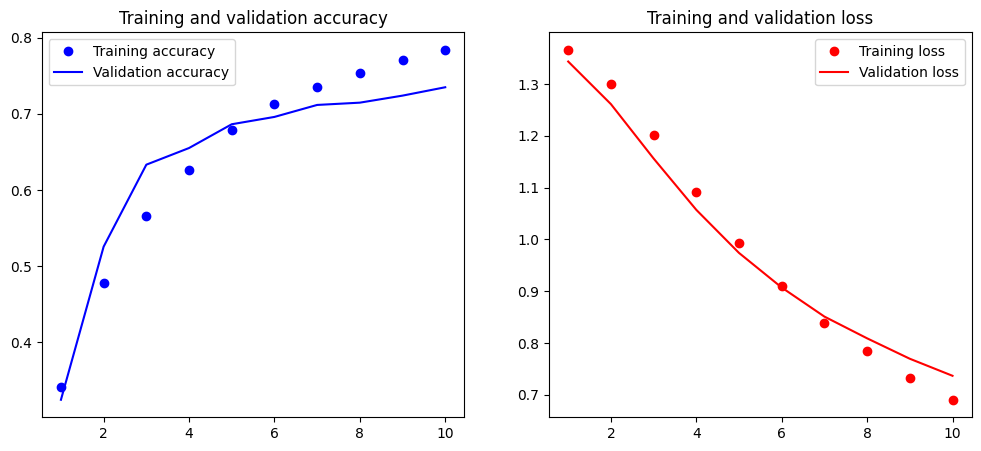

In [112]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [113]:
loss, accuracy = model.evaluate(val_ds)
print("Validation accuracy:", accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7350 - loss: 0.7367
Validation accuracy: 0.7350000143051147
